## Telecom Customer Churn Analysis Project

## 1. Import Required Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [38]:
df= pd.read_csv("D:\\Projects\\telecom_customer_churn_analysis\\dataset\\telecom_customer_churn_excel_cleaned.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## 3. Basic Data Exploration

In [40]:
df.shape

(7043, 21)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [44]:
df.describe().round()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.0,7043.0,7043.0
mean,0.0,32.0,65.0
std,0.0,25.0,30.0
min,0.0,0.0,18.0
25%,0.0,9.0,36.0
50%,0.0,29.0,70.0
75%,0.0,55.0,90.0
max,1.0,72.0,119.0


## 4. Data Quality Analysis

In [45]:
df.columns=df.columns.str.strip().str.title()

## I. Check Duplicate Row

In [46]:
df.duplicated().sum()

np.int64(0)

## II.Check Missing Values

In [47]:
df.isnull().sum()

Customerid          0
Gender              0
Seniorcitizen       0
Partner             0
Dependents          0
Tenure              0
Phoneservice        0
Multiplelines       0
Internetservice     0
Onlinesecurity      0
Onlinebackup        0
Deviceprotection    0
Techsupport         0
Streamingtv         0
Streamingmovies     0
Contract            0
Paperlessbilling    0
Paymentmethod       0
Monthlycharges      0
Totalcharges        0
Churn               0
dtype: int64

## 5. Data Cleaning

In [48]:
df[df['Totalcharges'] == ' ']

,Customerid,Gender,Seniorcitizen,Partner,Dependents,Tenure,Phoneservice,Multiplelines,Internetservice,Onlinesecurity,...,Deviceprotection,Techsupport,Streamingtv,Streamingmovies,Contract,Paperlessbilling,Paymentmethod,Monthlycharges,Totalcharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


### 5.1 Convert TotalCharges to Numeric

In [49]:
df['Totalcharges'] = pd.to_numeric(df['Totalcharges'],errors='coerce')

In [50]:
df.isnull().sum()

Customerid           0
Gender               0
Seniorcitizen        0
Partner              0
Dependents           0
Tenure               0
Phoneservice         0
Multiplelines        0
Internetservice      0
Onlinesecurity       0
Onlinebackup         0
Deviceprotection     0
Techsupport          0
Streamingtv          0
Streamingmovies      0
Contract             0
Paperlessbilling     0
Paymentmethod        0
Monthlycharges       0
Totalcharges        11
Churn                0
dtype: int64

In [51]:
df[df['Totalcharges'].isnull()]

,Customerid,Gender,Seniorcitizen,Partner,Dependents,Tenure,Phoneservice,Multiplelines,Internetservice,Onlinesecurity,...,Deviceprotection,Techsupport,Streamingtv,Streamingmovies,Contract,Paperlessbilling,Paymentmethod,Monthlycharges,Totalcharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


## 5.2 Handle Missing Values

In [52]:
df = df.dropna()

In [53]:
df.isnull().sum()

Customerid          0
Gender              0
Seniorcitizen       0
Partner             0
Dependents          0
Tenure              0
Phoneservice        0
Multiplelines       0
Internetservice     0
Onlinesecurity      0
Onlinebackup        0
Deviceprotection    0
Techsupport         0
Streamingtv         0
Streamingmovies     0
Contract            0
Paperlessbilling    0
Paymentmethod       0
Monthlycharges      0
Totalcharges        0
Churn               0
dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customerid        7032 non-null   object 
 1   Gender            7032 non-null   object 
 2   Seniorcitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   Tenure            7032 non-null   int64  
 6   Phoneservice      7032 non-null   object 
 7   Multiplelines     7032 non-null   object 
 8   Internetservice   7032 non-null   object 
 9   Onlinesecurity    7032 non-null   object 
 10  Onlinebackup      7032 non-null   object 
 11  Deviceprotection  7032 non-null   object 
 12  Techsupport       7032 non-null   object 
 13  Streamingtv       7032 non-null   object 
 14  Streamingmovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  Paperlessbilling  7032 non-null   object 
 17  

## 5.3 Create Tenure Group

In [56]:
bins = [0,12,24,48,72]
labels = ['0-1 Year','1-2 Years','2-4 Years','4-6 Years']

df['Tenure_Group'] = pd.cut(df['Tenure'],bins=bins,labels=labels)

C:\Users\sushil\AppData\Local\Temp\ipykernel_12564\577959423.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tenure_Group'] = pd.cut(df['Tenure'],bins=bins,labels=labels)


In [57]:
df['Tenure_Group'].value_counts()

Tenure_Group
4-6 Years    2239
0-1 Year     2175
2-4 Years    1594
1-2 Years    1024
Name: count, dtype: int64

In [58]:
df['Seniorcitizen'] = df['Seniorcitizen'].replace({0:'Non-Senior',1:'Senior'})

C:\Users\sushil\AppData\Local\Temp\ipykernel_12564\4235160591.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Seniorcitizen'] = df['Seniorcitizen'].replace({0:'Non-Senior',1:'Senior'})


In [59]:
df['Seniorcitizen'].value_counts()

Seniorcitizen
Non-Senior    5890
Senior        1142
Name: count, dtype: int64

## 6. Exploratory Data Analysis (EDA)

## Churn Rate Analysis

In [60]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [61]:
(df['Churn'].value_counts(normalize=True)*100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

## Insight:
## Approximately 26.58% customers have churned while 73.42% customers are retained.

## Churn by Gender

In [62]:
pd.crosstab(df['Gender'],df['Churn'],normalize='index')*100

Churn,No,Yes
Gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


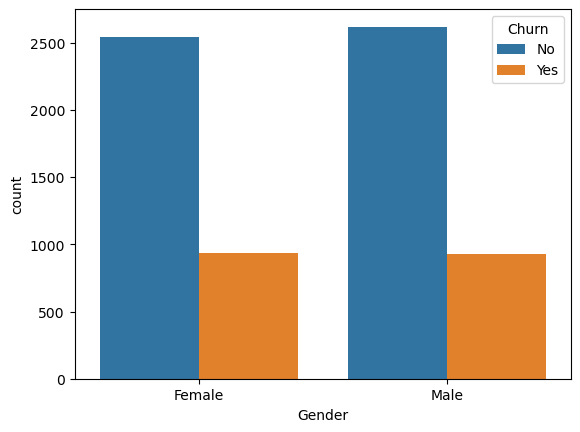

In [63]:
sns.countplot(data=df,x='Gender',hue='Churn')
plt.show()

## Insight: 
## Gender has minimal impact on customer churn.

## Churn by Contract Type

In [64]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


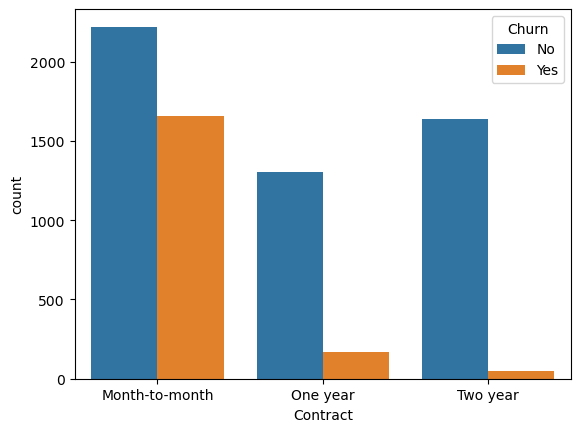

In [65]:
sns.countplot(data=df,x='Contract',hue='Churn')
plt.show()

# Insight 
# Month-to-months contract type customers are more likely to be churned as compared to others.

## Churn by Payment Method

In [66]:
pd.crosstab(df['Paymentmethod'],df['Churn'],normalize='index')*100

Churn,No,Yes
Paymentmethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


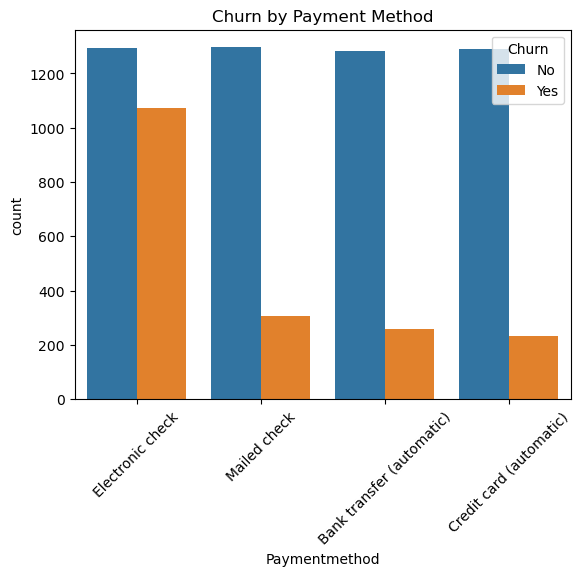

In [67]:
sns.countplot(data=df,x='Paymentmethod',hue='Churn')
plt.xticks(rotation=45)
plt.title('Churn by Payment Method')
plt.show()

## Insight:
## Customers using Electronic Check show the highest churn rate.

##  Churn by Internet Service

In [68]:
pd.crosstab(df['Internetservice'],df['Churn'],normalize='index')*100

Churn,No,Yes
Internetservice,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


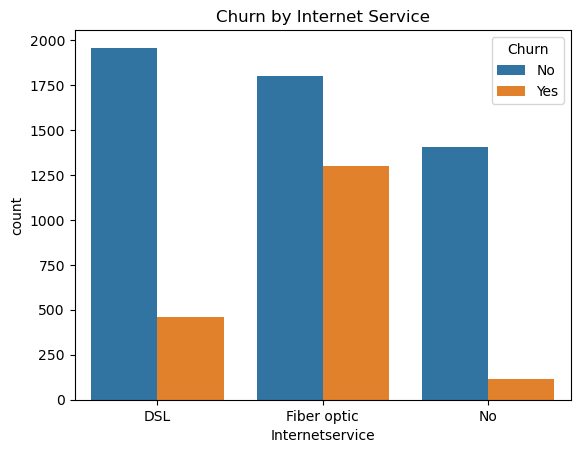

In [69]:
sns.countplot(data=df,x='Internetservice',hue='Churn')
plt.title('Churn by Internet Service')
plt.show()

## Insight:
## Fiber Optic customers have a higher churn rate compared to DSL customers.

## Churn by Tenure Group

In [71]:
pd.crosstab(df['Tenure_Group'],df['Churn'],normalize='index')*100

Churn,No,Yes
Tenure_Group,,
0-1 Year,52.321839,47.678161
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
4-6 Years,90.486824,9.513176


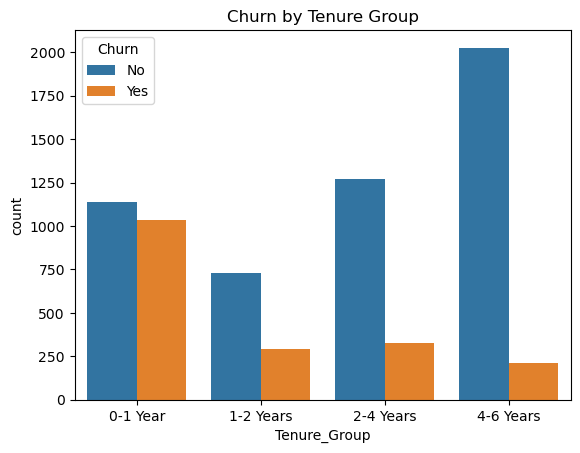

In [72]:
sns.countplot(data=df,x='Tenure_Group',hue='Churn')
plt.title('Churn by Tenure Group')
plt.show()

## Insight:
## Customers in their first year are more likely to churn than long-term customers.

## Monthly Charges vs Churn

In [73]:
df.groupby('Churn')['Monthlycharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: Monthlycharges, dtype: float64

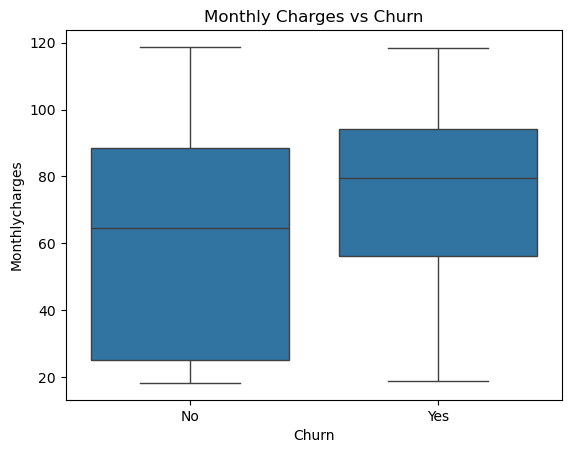

In [75]:
sns.boxplot(data=df, x='Churn', y='Monthlycharges')
plt.title('Monthly Charges vs Churn')
plt.show()

## Insight:
## Customers who churn have higher average monthly charges (74.44) compared to retained customers (61.31), 
## suggesting that higher pricing may contribute to customer attrition.

## Total Charges vs Churn

In [76]:
df.groupby('Churn')['Totalcharges'].mean()

Churn
No     2555.344141
Yes    1531.796094
Name: Totalcharges, dtype: float64

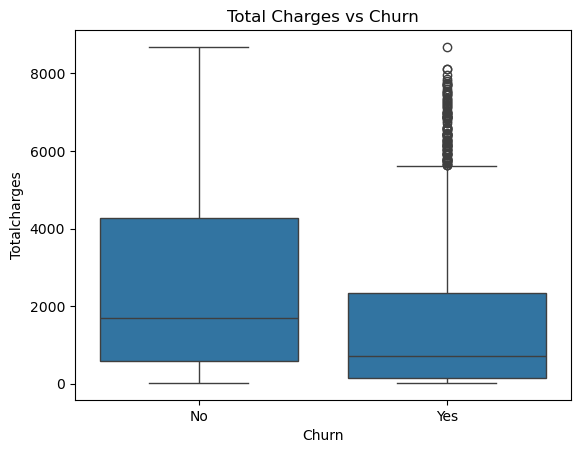

In [77]:
sns.boxplot(data=df, x='Churn', y='Totalcharges')
plt.title('Total Charges vs Churn')
plt.show()

## Insight:
## Churned customers have lower average total charges than retained customers, indicating that customers tend to leave earlier in their lifecycle before accumulating high total spending.

## 7. Key Business Insights

##  Export Clean Data

In [78]:
df.to_csv("telecom_customer_churn_cleaned.csv",index=False)

In [79]:
df.shape

(7032, 22)

In [81]:
df['Totalcharges'].dtype

dtype('float64')

In [82]:
df.isnull().sum()

Customerid          0
Gender              0
Seniorcitizen       0
Partner             0
Dependents          0
Tenure              0
Phoneservice        0
Multiplelines       0
Internetservice     0
Onlinesecurity      0
Onlinebackup        0
Deviceprotection    0
Techsupport         0
Streamingtv         0
Streamingmovies     0
Contract            0
Paperlessbilling    0
Paymentmethod       0
Monthlycharges      0
Totalcharges        0
Churn               0
Tenure_Group        0
dtype: int64